# 03 整日概率回归链

输入为日历变量、前1/7天同时刻观测、近7日均值以及当日已经生成的前两个时刻；输出为下一时刻负荷/PV条件分布，按144步递推形成整日联合概率场景。

所有结果只保存在 Notebook 输出中，不写出图片、表格或缓存文件。预测评价期为 2025-02-01 至 2025-12-31；题目给定的初始储能为 6000 kWh，但本 Notebook 只评价预测层，因此不计算调度费用。

In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "C题.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = pd.read_csv(ROOT / "q2/input/q2_actual_load_pv.csv", encoding="utf-8-sig")
DATES = pd.DatetimeIndex(pd.to_datetime(DATA["date"].drop_duplicates()))
LOAD = DATA["load_kw"].to_numpy(float).reshape(-1, 144)
PV = DATA["pv_kw"].to_numpy(float).reshape(-1, 144)
EVAL_START = pd.Timestamp("2025-02-01")
EVAL_IDX = np.where(DATES >= EVAL_START)[0]
SLOTS = np.arange(144)
INITIAL_STORAGE_KWH = 6000.0  # 题目给定的 2025-01-01 00:00 初始储能
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .25})

def crps_ensemble(samples, actual):
    # CRPS = E|X-y| - 1/2 E|X-X'|；排序形式避免构造 S×S 矩阵
    z = np.sort(samples, axis=0)
    s = len(z)
    w = (2*np.arange(1, s+1)-1-s)[:, None]
    return np.abs(z-actual).mean(axis=0) - (w*z).sum(axis=0)/(s*s)

def evaluate_forecast(centres_load, centres_pv, scenario_days):
    rows, q10s, q90s, q05s, q95s = [], [], [], [], []
    for d in EVAL_IDX:
        cnet = centres_load[d] - centres_pv[d]
        actual = LOAD[d] - PV[d]
        scen = scenario_days[d]
        q05, q10, q90, q95 = np.quantile(scen, [.05, .10, .90, .95], axis=0)
        rows.append({
            "date": DATES[d],
            "mae_kw": np.abs(cnet-actual).mean(),
            "rmse_kw": np.sqrt(np.mean((cnet-actual)**2)),
            "crps_kw": crps_ensemble(scen, actual).mean(),
            "cover80": np.mean((actual >= q10) & (actual <= q90)),
            "cover90": np.mean((actual >= q05) & (actual <= q95)),
            "width80_kw": np.mean(q90-q10),
            "width90_kw": np.mean(q95-q05),
        })
        q10s.append(q10); q90s.append(q90); q05s.append(q05); q95s.append(q95)
    daily = pd.DataFrame(rows)
    summary = pd.DataFrame({
        "metric": ["MAE (kW)", "RMSE (kW)", "CRPS (kW)", "80% coverage", "90% coverage", "80% width (kW)", "90% width (kW)"],
        "value": [daily.mae_kw.mean(), daily.rmse_kw.mean(), daily.crps_kw.mean(), daily.cover80.mean(), daily.cover90.mean(), daily.width80_kw.mean(), daily.width90_kw.mean()]
    })
    bands = {"q10": np.array(q10s), "q90": np.array(q90s), "q05": np.array(q05s), "q95": np.array(q95s)}
    return daily, summary, bands

def plot_diagnostics(model_name, centres_load, centres_pv, scenario_days, daily, bands):
    # 指定日概率扇形图
    d = int(np.where(DATES == pd.Timestamp("2025-06-21"))[0][0])
    x = SLOTS / 6
    scen = scenario_days[d]
    q05, q10, q90, q95 = np.quantile(scen, [.05, .10, .90, .95], axis=0)
    center = centres_load[d] - centres_pv[d]
    actual = LOAD[d] - PV[d]
    fig, ax = plt.subplots()
    ax.fill_between(x, q05, q95, alpha=.18, label="90% interval")
    ax.fill_between(x, q10, q90, alpha=.28, label="80% interval")
    ax.plot(x, actual, color="black", lw=1.5, label="actual net load")
    ax.plot(x, center, color="tab:red", lw=1.2, label="center forecast")
    ax.set(title=f"{model_name}: 2025-06-21", xlabel="hour", ylabel="kW")
    ax.legend(ncol=2); plt.show()

    monthly = daily.assign(month=daily.date.dt.month).groupby("month")[["mae_kw", "crps_kw"]].mean()
    monthly.plot(marker="o", title=f"{model_name}: monthly forecast scores", ylabel="kW")
    plt.show()

    cov = [daily.cover80.mean(), daily.cover90.mean()]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["80% interval", "90% interval"], cov, color=["#4c78a8", "#72b7b2"])
    ax.scatter([0, 1], [.8, .9], color="black", zorder=3, label="nominal")
    ax.set_ylim(0, 1); ax.set_ylabel("empirical coverage"); ax.set_title(f"{model_name}: calibration")
    ax.legend(); plt.show()


In [2]:

def calendar_vector(date):
    dow = date.weekday(); doy = date.dayofyear
    return np.array([np.sin(2*np.pi*dow/7), np.cos(2*np.pi*dow/7),
                     np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25),
                     float(dow in (4, 5))])

def fit_chain(target_day, window=120, alpha=15.0):
    h0 = max(7, target_day-window)
    days = np.arange(h0, target_day)
    load_models, pv_models, innovations = [], [], []
    for t in range(144):
        prev1 = max(t-1, 0); prev2 = max(t-2, 0)
        common = np.vstack([np.r_[calendar_vector(DATES[j]),
                                  LOAD[j-1,t], PV[j-1,t], LOAD[j-7,t], PV[j-7,t],
                                  LOAD[j-7:j,t].mean(), PV[j-7:j,t].mean()]
                            for j in days])
        xl = np.column_stack([common, LOAD[days,prev1], LOAD[days,prev2]])
        ml = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(xl, LOAD[days,t])
        load_fit = ml.predict(xl)
        xp = np.column_stack([common, PV[days,prev1], PV[days,prev2], LOAD[days,t]])
        mp = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(xp, PV[days,t])
        pv_fit = mp.predict(xp)
        load_models.append(ml); pv_models.append(mp)
        innovations.append(np.column_stack([LOAD[days,t]-load_fit, PV[days,t]-pv_fit]))
    return days, load_models, pv_models, innovations

def generate_chain(day, fitted, n_scenarios=100, seed=2026):
    days, load_models, pv_models, innovations = fitted
    rng = np.random.default_rng(seed+day)
    ls = np.zeros((n_scenarios,144)); ps = np.zeros((n_scenarios,144))
    center_l = np.zeros(144); center_p = np.zeros(144)
    base = calendar_vector(DATES[day])
    for t in range(144):
        p1=max(t-1,0); p2=max(t-2,0)
        common0=np.r_[base, LOAD[day-1,t], PV[day-1,t], LOAD[day-7,t], PV[day-7,t],
                      LOAD[day-7:day,t].mean(), PV[day-7:day,t].mean()]
        xlc=np.r_[common0, center_l[p1], center_l[p2]][None,:]
        center_l[t]=max(float(load_models[t].predict(xlc)[0]),0)
        xpc=np.r_[common0, center_p[p1], center_p[p2], center_l[t]][None,:]
        center_p[t]=max(float(pv_models[t].predict(xpc)[0]),0)

        common=np.repeat(common0[None,:], n_scenarios, axis=0)
        xl=np.column_stack([common,ls[:,p1],ls[:,p2]])
        mu_l=load_models[t].predict(xl)
        # 同一情景沿日内连续地移动历史行，保留负荷/PV创新的配对相关性
        idx=(rng.integers(0,len(days),n_scenarios)+t) % len(days)
        ls[:,t]=np.maximum(mu_l+innovations[t][idx,0],0)
        xp=np.column_stack([common,ps[:,p1],ps[:,p2],ls[:,t]])
        mu_p=pv_models[t].predict(xp)
        ps[:,t]=np.maximum(mu_p+innovations[t][idx,1],0)
    return center_l, center_p, ls-ps

centres_load=np.full_like(LOAD,np.nan); centres_pv=np.full_like(PV,np.nan)
scenario_days={}; fitted=None
for d in range(14,len(DATES)):
    if fitted is None or (d-14)%7==0:
        fitted=fit_chain(d)
    cl,cp,scen=generate_chain(d,fitted)
    centres_load[d]=cl; centres_pv[d]=cp; scenario_days[d]=scen

daily, summary, bands = evaluate_forecast(centres_load, centres_pv, scenario_days)


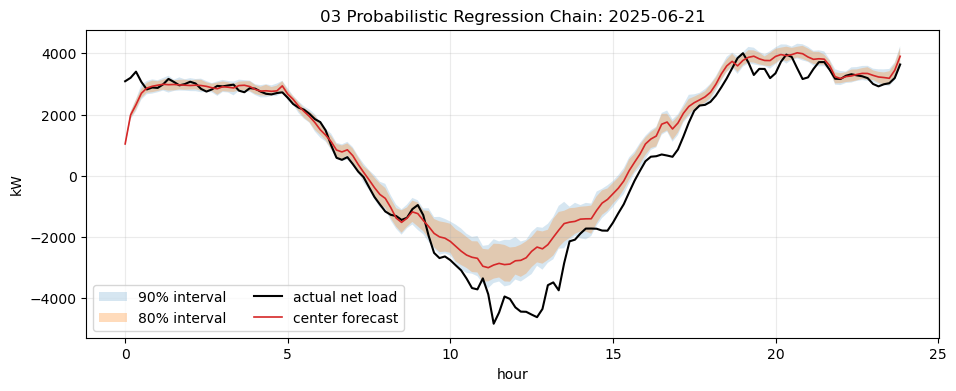

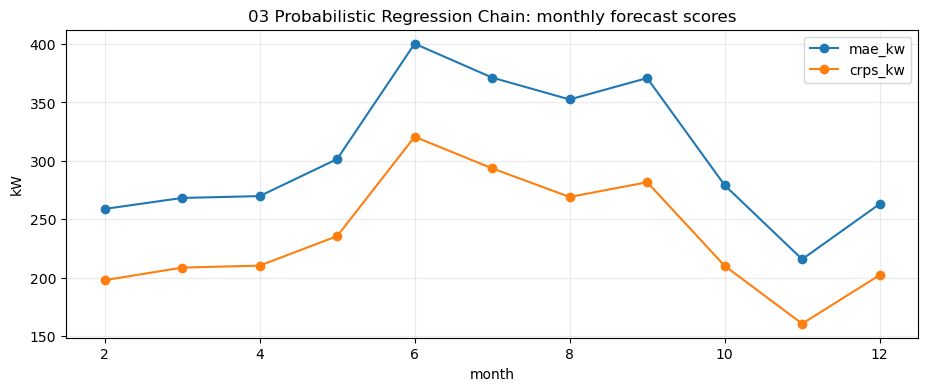

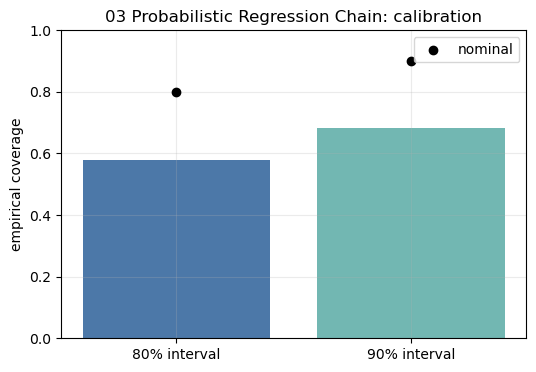

In [3]:
MODEL_NAME="03 Probabilistic Regression Chain"
plot_diagnostics(MODEL_NAME, centres_load, centres_pv, scenario_days, daily, bands)

## 拟合效果汇总

MAE/RMSE 衡量中心预测误差；CRPS 综合衡量整个概率分布，三者越小越好。覆盖率应分别接近 0.8 和 0.9；区间宽度越小表示预测越尖锐。

In [4]:
summary = summary.copy()
summary.insert(0, 'model', MODEL_NAME)
display(summary.round(4))

,model,metric,value
0,03 Probabilistic Regression Chain,MAE (kW),304.9218
1,03 Probabilistic Regression Chain,RMSE (kW),440.7542
2,03 Probabilistic Regression Chain,CRPS (kW),235.6177
3,03 Probabilistic Regression Chain,80% coverage,0.5776
4,03 Probabilistic Regression Chain,90% coverage,0.6818
5,03 Probabilistic Regression Chain,80% width (kW),535.3143
6,03 Probabilistic Regression Chain,90% width (kW),682.0279
